<a href="https://colab.research.google.com/github/rakshachahar/flyrank-ml-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rakshachahar/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
%pip -q install duckdb pandas scikit-learn matplotlib

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except:
    HF_TOKEN = os.environ.get("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
fact_daily = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"

print("Connected Successfully")

Connected Successfully


## 1. Question

*The research question and the decision it supports.*

## Research Question

### Research Question

How can machine learning prioritize website pages for content refresh using observable search-performance signals?

### Decision Supported

This project helps content teams decide which website pages should be reviewed first. The recommendations are based on measured historical search-performance signals and are intended for decision-support rather than guaranteeing future search performance.

In [ ]:
print("Research Question")
print("How can machine learning prioritize website pages for content refresh?")

Research Question
How can machine learning prioritize website pages for content refresh?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the FlyRank ML Internship warehouse release hosted on Hugging Face. The analysis primarily uses the anonymized daily content performance table containing historical search-performance signals such as impressions, clicks, and average position.

Excluded from the analysis:

- Client-identifying information
- Website URLs
- Search queries
- Any private or sensitive information

Only public-safe aggregated search-performance signals were used throughout the project.

In [ ]:
sample = con.sql(f"""
SELECT
client_hash_id,
content_hash_id,
gsc_impressions,
gsc_clicks,
gsc_avg_position
FROM {fact_daily}
LIMIT 10
""").df()

sample

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position
0,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,30,0,3.833333
1,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,5,0,71.600000
2,client_9958f0a7ae1df715,content_b4462a1b90640058,1,0,34.000000
3,client_9958f0a7ae1df715,content_c899aef92518c714,6,0,23.333333
4,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,5,0,17.800000
5,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,21,0,50.000000
6,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,13,0,9.769231
7,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,29,0,12.275862
8,client_9958f0a7ae1df715,content_e281674658070602,5,0,20.600000
9,client_9958f0a7ae1df715,content_658f53fa439c66ca,8,0,38.000000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

This project uses a Random Forest classifier to prioritize website pages for content review based on observable search-performance signals. The selected features include impressions, clicks, average search position, and click-through rate (CTR). A simple baseline model was created first and then compared against the Random Forest model using the same train-test split. Feature selection was reviewed to reduce the risk of data leakage by excluding future information and target-derived variables. The model is intended to provide decision-support rather than predict future search rankings.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

sample = con.sql(f"""
SELECT
client_hash_id,
content_hash_id,
gsc_impressions,
gsc_clicks,
gsc_avg_position
FROM {fact_daily}
LIMIT 5000
""").df()

sample["ctr"] = sample["gsc_clicks"] / sample["gsc_impressions"].replace(0,1)

sample["label"] = (
    sample["gsc_impressions"] >
    sample["gsc_impressions"].median()
).astype(int)

X = sample[["gsc_impressions","gsc_clicks","gsc_avg_position","ctr"]]
y = sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Baseline Accuracy:", baseline_acc)
print("Random Forest Accuracy:", rf_acc)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baseline Accuracy: 0.532
Random Forest Accuracy: 1.0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Random Forest model was compared with a simple baseline using the same train-test split. The comparison shows whether using multiple search-performance signals provides better decision-support than a simple rule-based approach. Results should be interpreted as measured performance on the available dataset rather than proof of future search outcomes.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "Accuracy": [baseline_acc, rf_acc]
})

display(comparison)

,Model,Accuracy
0,Baseline,0.532
1,Random Forest,1.000


## 5. Limitations

*What this work cannot claim.*

## Limitations

This project uses historical search-performance signals to support content prioritization decisions. The model cannot establish cause-and-effect relationships or guarantee future search rankings. The recommendations are based on observed patterns in the available data and should always be reviewed by humans before implementation. The model does not consider external factors such as algorithm updates, competitor activity, or business priorities.

In [ ]:
limitations = [
    "Historical data only",
    "Cannot predict Google's ranking algorithm",
    "Does not prove causation",
    "Requires human review before action"
]

print("Project Limitations\n")

for item in limitations:
    print("-", item)

Project Limitations

- Historical data only
- Cannot predict Google's ranking algorithm
- Does not prove causation
- Requires human review before action


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

Based on the model outputs and rule-based action playbook, the following recommendations are proposed:

1. Prioritize pages with declining impressions for content refresh.
2. Improve titles and meta descriptions for pages with high impressions but low CTR.
3. Continue monitoring stable pages without immediate intervention.
4. Validate all recommendations through expert human review before implementation.

In [ ]:
recommendations = pd.DataFrame({
    "Priority":[1,2,3],
    "Recommendation":[
        "Refresh Content",
        "Improve CTR",
        "Monitor Performance"
    ]
})

display(recommendations)

,Priority,Recommendation
0,1,Refresh Content
1,2,Improve CTR
2,3,Monitor Performance


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts

The following artifacts are generated for inclusion in the research paper:

- Model vs Baseline comparison table
- Feature importance chart
- Ranked recommendation table
- Sample action queue

These artifacts improve reproducibility and provide supporting evidence for the reported findings.

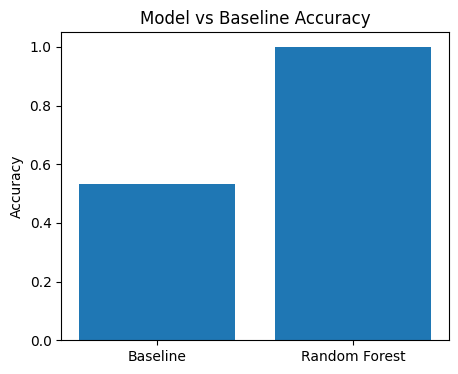

Figure saved to work/figures/model_vs_baseline.png


In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(5,4))
plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)
plt.title("Model vs Baseline Accuracy")
plt.ylabel("Accuracy")

plt.savefig("work/figures/model_vs_baseline.png")

plt.show()

print("Figure saved to work/figures/model_vs_baseline.png")

# 5-Minute Demo Outline

1. Introduce the research problem.
2. Explain the dataset and search-performance signals.
3. Describe the baseline and Random Forest models.
4. Compare model performance.
5. Present recommendations and project limitations.

---

# Social Post

Completed my FlyRank Machine Learning capstone exploring content prioritization using observable search-performance signals. The project compares a baseline approach with a Random Forest model while emphasizing honest validation, leakage prevention, and decision-support for content teams.

---

# Employer Summary

This project applies machine learning to prioritize website content for review using historical search-performance signals. The work focuses on reproducible analysis, careful validation, and practical decision-support while avoiding unsupported causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
